# Customer Shopping Behavior Analysis (ML + NLP)

#Project Objective

- Analyze customer purchase behavior

- Predict outcomes (e.g., subscription, spending)

- Extract insights from text reviews using NLP

- Build a machine learning model

- Create insights for business decisions

#Tech Stack

Python (Google Colab)

Pandas, NumPy

Matplotlib, Seaborn

Scikit-learn (ML)

NLTK / TextBlob (NLP)

WordCloud

#Dataset

Use dataset like:

- Customer shopping behavior dataset (CSV)

#Columns example:

- Age

- Gender

- Purchase Amount

- Product Category

- Previous Purchases

- Subscription Status

- Review Text (for NLP)

#1. Google Colab Setup

In [11]:
# Install libraries
!pip install nltk textblob wordcloud

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#2. Upload & Load Dataset

In [12]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving customer_shopping_behavior.csv to customer_shopping_behavior (4).csv


#3. Understand Data

In [13]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  0 non-null      float64
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

,0
Customer ID,0
Age,0
Gender,3900
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


#4. Data Cleaning

In [20]:
# Fill missing reviews (This block will not execute if 'Review' column is not present)
if 'Review' in df.columns:
    df['Review'] = df['Review'].fillna("No Review")

# Fill missing 'Review Rating' with the mean of the column
if 'Review Rating' in df.columns:
    df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].mean())

# Encode categorical columns (original code)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

if 'Subscription' in df.columns:
    df['Subscription'] = df['Subscription'].map({'Yes': 1, 'No': 0})

#5. Feature Engineering

In [15]:
# Customer segmentation
if 'Previous Purchases' in df.columns:
    df['Customer_Type'] = df['Previous Purchases'].apply(
        lambda x: 'New' if x == 0 else ('Returning' if x <= 5 else 'Loyal')
    )

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Customer_Type
0,1,55,NaN,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Loyal
1,2,19,NaN,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Returning
2,3,50,NaN,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Loyal
3,4,21,NaN,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Loyal
4,5,45,NaN,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Loyal


#6. Exploratory Data Analysis (EDA)

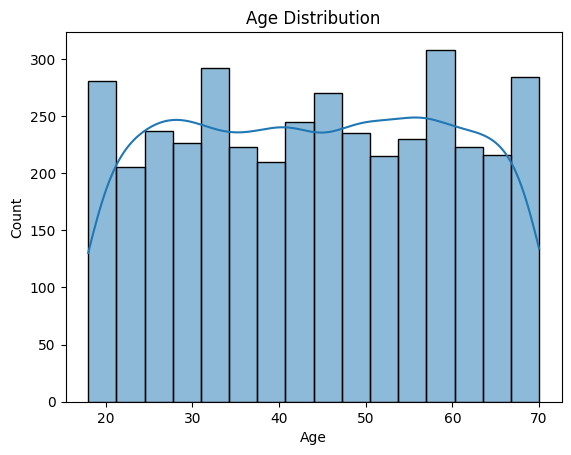

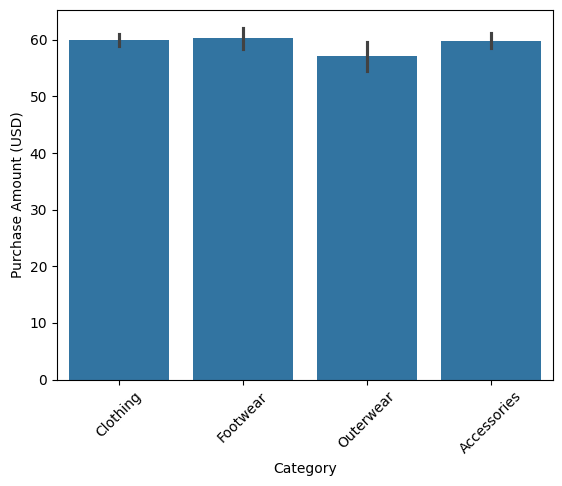

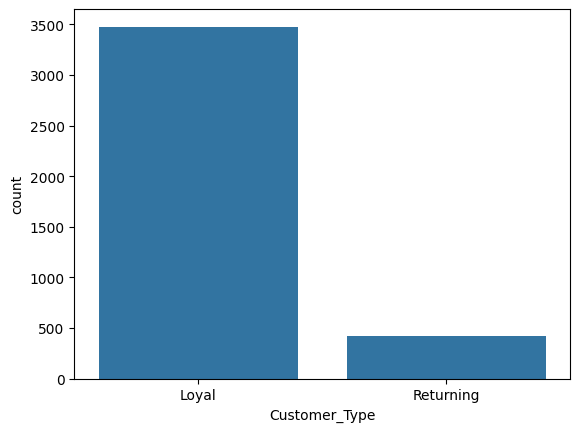

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution
if 'Age' in df.columns:
    sns.histplot(df['Age'], kde=True)
    plt.title("Age Distribution")
    plt.show()

# Purchase vs Category
if 'Category' in df.columns:
    sns.barplot(x='Category', y='Purchase Amount (USD)', data=df) # Corrected column name
    plt.xticks(rotation=45)
    plt.show()

# Customer type count
sns.countplot(x='Customer_Type', data=df)
plt.show()

#7. NLP – Text Preprocessing

#Step 1: Preprocessing

In [18]:
import nltk
import string
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

if 'Review' in df.columns:
    df['Clean_Review'] = df['Review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#Step 2: Sentiment Scoring

In [24]:
# TextBlob and text-based sentiment analysis is not applicable as there is no text 'Review' column.
# We will use 'Review Rating' to infer sentiment.

if 'Review Rating' in df.columns:
    # Assign numerical 'Sentiment' directly from 'Review Rating'
    df['Sentiment'] = df['Review Rating']

    # Define a function to map numerical ratings to sentiment labels
    def map_rating_to_sentiment_label(rating):
        if rating >= 4.0:
            return 'Positive'
        elif rating >= 3.0:
            return 'Neutral'
        else:
            return 'Negative'

    # Apply the function to create the 'Sentiment_Label' column
    df['Sentiment_Label'] = df['Review Rating'].apply(map_rating_to_sentiment_label)
else:
    print("Review Rating column not found for sentiment analysis. Please check your DataFrame.")

#Step 3: Sentiment Category

In [25]:
df['Sentiment_Label'] = df['Sentiment'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)

#Sentiment Visualization

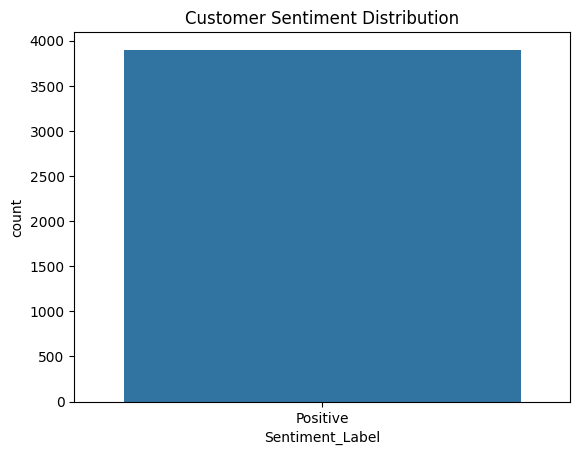

In [26]:
sns.countplot(x='Sentiment_Label', data=df)
plt.title("Customer Sentiment Distribution")
plt.show()

#8. Feature Engineering

In [28]:
# Select features
features = ['Age', 'Gender', 'Purchase Amount (USD)', 'Previous Purchases', 'Sentiment']
X = df[features]
y = df['Subscription Status']

#9. Machine Learning Model

Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Model Training (Random Forest)

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

Evaluation

In [31]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7128205128205128
              precision    recall  f1-score   support

          No       0.73      0.95      0.83       570
         Yes       0.32      0.06      0.10       210

    accuracy                           0.71       780
   macro avg       0.52      0.51      0.46       780
weighted avg       0.62      0.71      0.63       780



#10. WordCloud Visualization

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Check if 'Clean_Review' column exists before proceeding
if 'Clean_Review' in df.columns:
    text = " ".join(df['Clean_Review'])
    if text:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('Word Cloud of Cleaned Reviews')
        plt.show()
    else:
        print("No text available in 'Clean_Review' column to generate WordCloud.")
else:
    print("The 'Clean_Review' column does not exist in the DataFrame. WordCloud cannot be generated.")
    print("This is likely because the original dataset did not contain a 'Review' text column.")

The 'Clean_Review' column does not exist in the DataFrame. WordCloud cannot be generated.
This is likely because the original dataset did not contain a 'Review' text column.


#11. Importance Feature

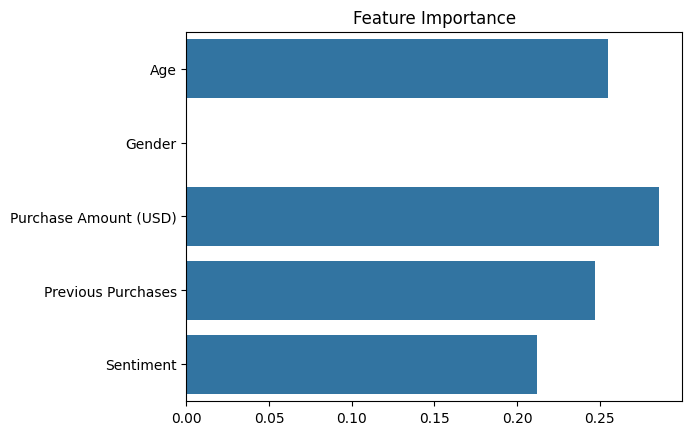

In [34]:
importances = model.feature_importances_
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()